# Notebook 3.5 — Avaliação Paciente-Específica (verificação do pipeline)

## Propósito

Este notebook não corresponde a um dos cenários de generalização do estudo. É uma verificação de integridade do pipeline: treina e testa um modelo no **mesmo paciente**, com separação cronológica, para confirmar que as features extraídas e os rótulos gerados são informativos antes de avaliar generalização.

A lógica é direta: se o modelo não consegue distinguir pré-ictal de interictal nem com dados do próprio paciente, há um problema de implementação — e avaliar generalização seria prematuro. Se o desempenho é alto aqui mas cai nos cenários A, B e C do Notebook 4, a queda é consequência da dificuldade real de generalização, não de defeito no código.

## Protocolo de treino e teste

### Partição dos dados

As partições de treino e teste são geradas no Notebook 3 com **separação cronológica**: as gravações mais antigas de cada paciente compõem o treino e as mais recentes compõem o teste. Não há embaralhamento temporal.

- **Treino**: janelas de 30 s extraídas com passo de 30 s, balanceadas 1:1 (interictal:pré-ictal) por amostragem estratificada no tempo. Usa gravações com e sem crise (CHB-MIT e SeizeIT2 têm gravações inteiramente sem crise como fonte de interictal; Siena e Mendeley usam o intervalo intra-arquivo distante das crises).
- **Teste**: janelas de 30 s extraídas com passo de 15 s, em **distribuição natural** (sem balanceamento). O número de janelas interictais é muito maior que o de pré-ictais, refletindo a proporção real do sinal. Todas as gravações do paciente entram no teste, incluindo aquelas sem crise que fornecem interictal puro.

### Modelos e normalização

Três modelos são comparados: Random Forest (RF), XGBoost (XGB) e Regressão Logística (LR). Para cada combinação de paciente, nível de canais e modelo:

1. O `StandardScaler` é ajustado exclusivamente no conjunto de treino e aplicado ao teste sem vazamento de informação.
2. O limiar de decisão é estimado pelo **índice de Youden** no conjunto de treino (maximiza sensibilidade + especificidade − 1), sem usar o teste para escolha do limiar.

### Métricas

Métricas por janela (avaliam a qualidade da probabilidade estimada):

| Métrica | Descrição |
|---|---|
| AUC-ROC | área sob a curva ROC; independente do limiar |
| Acurácia | proporção de janelas classificadas corretamente |
| Sensibilidade | proporção de janelas pré-ictais corretamente identificadas |
| Especificidade | proporção de janelas interictais corretamente identificadas |
| F1 | média harmônica de precisão e sensibilidade |
| Precisão | proporção das janelas classificadas como pré-ictal que são realmente pré-ictais |

Métricas por evento clínico (avaliam o comportamento do sistema de alarme):

| Métrica | Descrição |
|---|---|
| Sensibilidade por evento | proporção de crises para as quais o alarme disparou (∈ [0, 1]) |
| FAR/h | falsos alarmes por hora (alarmes fora do período pré-ictal) |

O alarme dispara quando **N_CONSEC = 5 janelas consecutivas** são classificadas como pré-ictal (equivalente a ~60–75 s contínuos de classificação positiva). Cada evento pré-ictal é contado no máximo uma vez, independente de quantas vezes o alarme dispare durante o mesmo período.

### Níveis de canais

| Nível | Canais | Quantidade | Datasets |
|---|---|---|---|
| R5 | fp1, fp2, f7, f3, fz, f4, f8, t3, t4, t5, t6, c3, c4, p3, p4 | 15 | CHB-MIT, Siena, Mendeley |
| R3 | f7, f3, fz, f4, f8, t3, t4, t5, t6, c3, c4 | 11 | CHB-MIT, Siena, Mendeley |
| R2 | f7, f3, fz, f4, f8, t3, t4, t5, t6 | 9 | CHB-MIT, Siena, Mendeley |
| R1 | t3, t4, t5, t6 | 4 | CHB-MIT, Siena, Mendeley |
| R0 | t3, t4 | 2 | CHB-MIT, Siena, Mendeley, **SeizeIT2** |

O SeizeIT2 possui apenas eletrodos *behind-the-ear* (região temporal), por isso entra somente no nível R0.


## 1. Dependências e configuração

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost tqdm shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, glob, time, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score,
                             precision_score, accuracy_score, roc_curve)
import xgboost as xgb
from tqdm.auto import tqdm
import IPython.display as ipd

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

ROOT_DIR = 'data'
FEAT_DIR = os.path.join(ROOT_DIR, 'features')
RESULTS_DIR = os.path.join(ROOT_DIR, 'results'); FIG_DIR = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

N_CONSEC = 5; STEP_TEST_SEC = 15; WIN_SEC = 30; N_FEAT_CH = 19
VAL_FRAC = 0.2  # fração para o diagnóstico interno de overfitting (split por bloco temporal)
MODELS = ['RF', 'XGB', 'LR']
LEVELS = ['R5', 'R3', 'R2', 'R1', 'R0']
PATIENTS = {
    'CHBMIT'  : ['chb01','chb03','chb04','chb05','chb06','chb07','chb08','chb10','chb11','chb12','chb13','chb14'],
    'Siena'   : ['PN01','PN03','PN05','PN06','PN07','PN09','PN10','PN11','PN12','PN13','PN14','PN16'],
    'Mendeley': ['p10','p11','p12','p13','p14','p15'],
    'SeizeIT2': ['sub-001','sub-002','sub-003','sub-004','sub-005','sub-006','sub-007','sub-008','sub-009','sub-010','sub-011','sub-012'],
}
LEVEL_DS = {
    'R5': ['CHBMIT','Siena','Mendeley'], 'R3': ['CHBMIT','Siena','Mendeley'],
    'R2': ['CHBMIT','Siena','Mendeley'], 'R1': ['CHBMIT','Siena','Mendeley'],
    'R0': ['CHBMIT','Siena','Mendeley','SeizeIT2'],
}
print('Configuração carregada (avaliação paciente-específica).')

Configuração carregada (avaliação paciente-específica).


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Funções

As mesmas funções de modelagem e métrica usadas no Notebook 4, para garantir comparabilidade.


In [3]:
def load_feat(dataset, patient, level, mode):
    fp = os.path.join(FEAT_DIR, level, mode, f'{dataset}__{patient}.npz')
    if not os.path.exists(fp):
        return None, None
    z = np.load(fp, allow_pickle=True)
    return z['X'].copy(), z['y'].copy()

def youden_thr(y_tr, p_tr):
    fpr, tpr, thr = roc_curve(y_tr, p_tr)
    return float(thr[np.argmax(tpr - fpr)])

def get_model(name):
    if name == 'RF':
        return RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
            class_weight='balanced', n_jobs=4, random_state=42)
    if name == 'XGB':
        return xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
            n_jobs=4, random_state=42, eval_metric='logloss', verbosity=0)
    if name == 'LR':
        return LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
            solver='lbfgs', n_jobs=4, random_state=42)
    raise ValueError(name)

def compute_metrics(y_true, y_prob, thr, dur_h, n_consec=N_CONSEC):
    if len(np.unique(y_true)) < 2:
        return {}
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    far_w = fp / dur_h if dur_h > 0 else 0.0

    # Contar eventos pré-ictais (blocos contíguos de y_true==1)
    n_ev = 0; in_ev = False
    for v in y_true:
        if v == 1 and not in_ev:
            n_ev += 1; in_ev = True
        if v == 0:
            in_ev = False

    # Contagem de alarmes: no máximo 1 detecção por evento pré-ictal.
    # Após disparar um alarme, bloqueia novas contagens até que o período
    # pré-ictal termine (y_true volta a 0). Garante sens_event em [0, 1].
    consec = 0; alarm = False
    n_det = 0; n_fa = 0
    in_preictal = False; event_counted = False

    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and not in_preictal:
            in_preictal = True; event_counted = False
        if yt == 0:
            in_preictal = False; event_counted = False

        consec = (consec + 1) if yp == 1 else 0
        if consec >= n_consec and not alarm:
            alarm = True
            if not event_counted:
                if yt == 1:
                    n_det += 1; event_counted = True
                else:
                    n_fa += 1
        if yp == 0:
            alarm = False

    return dict(auc_roc=round(float(roc_auc_score(y_true, y_prob)), 4),
        accuracy=round(float(accuracy_score(y_true, y_pred)), 4),
        sensitivity=round(sens, 4), specificity=round(spec, 4),
        f1=round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        precision=round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        far_window_h=round(far_w, 4), threshold=round(thr, 4),
        sens_event=round(n_det / n_ev if n_ev > 0 else 0.0, 4),
        far_event_h=round(n_fa / dur_h if dur_h > 0 else 0.0, 4),
        n_events=int(n_ev), n_detected=int(n_det), n_false_alarms=int(n_fa),
        n_test_inter=int((y_true == 0).sum()), n_test_pre=int((y_true == 1).sum()))
def load_done(csv_path, keys):
    if not os.path.exists(csv_path):
        return set()
    df = pd.read_csv(csv_path); cols = [c for c in keys if c in df.columns]
    return set(zip(*[df[c] for c in cols]))

def save_row(row, csv_path):
    pd.DataFrame([row]).to_csv(csv_path, mode='a', header=not os.path.exists(csv_path), index=False)

def block_train_val_split(y, val_frac=0.2, seed=42):
    """Split de treino/validação por BLOCO TEMPORAL CONTÍNUO, não por janela
    individual — mesma lógica usada no Notebook 4.5 (DL), para manter
    comparabilidade metodológica entre ML e DL. Cada bloco é uma sequência
    contígua de janelas da mesma classe (um evento pré-ictal inteiro, ou um
    trecho interictal contínuo); blocos inteiros são sorteados para treino
    ou validação, nunca janelas soltas. Evita vazamento entre janelas
    vizinhas (quase idênticas em conteúdo de sinal).

    Usada aqui só como DIAGNÓSTICO de overfitting (gap AUC treino-validação)
    — o modelo final ainda treina com o conjunto de treino completo.

    Retorna (idx_treino, idx_val).
    """
    n = len(y)
    bounds = np.where(np.diff(y) != 0)[0] + 1
    starts = np.concatenate([[0], bounds])
    ends   = np.concatenate([bounds, [n]])
    blocks = [(s, e, y[s]) for s, e in zip(starts, ends)]

    rng = np.random.default_rng(seed)
    blocks_pre   = [b for b in blocks if b[2] == 1]
    blocks_inter = [b for b in blocks if b[2] == 0]
    rng.shuffle(blocks_pre); rng.shuffle(blocks_inter)

    def split_blocks(bl):
        n_tot = sum(e - s for s, e, _ in bl)
        target = n_tot * val_frac
        val_idx = []; acc = 0
        for s, e, _ in bl:
            if acc < target:
                val_idx.append((s, e)); acc += e - s
        val_set = set(val_idx)
        tr_idx  = [(s, e) for s, e, _ in bl if (s, e) not in val_set]
        return tr_idx, val_idx

    tr_pre, val_pre     = split_blocks(blocks_pre)
    tr_inter, val_inter = split_blocks(blocks_inter)

    def expand(bl):
        if not bl: return np.array([], dtype=int)
        return np.concatenate([np.arange(s, e) for s, e in bl])

    idx_tr  = np.sort(np.concatenate([expand(tr_pre),  expand(tr_inter)]))
    idx_val = np.sort(np.concatenate([expand(val_pre), expand(val_inter)]))

    if len(idx_val) == 0 or len(np.unique(y[idx_val])) < 2 or len(np.unique(y[idx_tr])) < 2:
        from sklearn.model_selection import train_test_split
        return train_test_split(np.arange(n), test_size=val_frac, stratify=y, random_state=seed)
    return idx_tr, idx_val

def overfit_diag(model_name, X_tr_sc, y_tr, val_frac=0.2, seed=42, n_estim_grid=None):
    """Diagnóstico de overfitting via gap AUC treino-validação, usando o
    mesmo split por bloco temporal do DL. Não altera o modelo final (que
    continua treinando com X_tr_sc/y_tr completos) — serve só para medir.

    Para RF/XGB: retorna também a curva AUC treino-vs-validação por número
    de árvores (n_estim_grid), análoga à curva por época do DL.
    Para LR: retorna só o gap (não há "número de árvores"/iteração comparável).

    Retorna dict com auc_tr_internal, auc_val_internal, gap, e curve (ou None).
    """
    idx_t, idx_v = block_train_val_split(y_tr, val_frac=val_frac, seed=seed)
    X_t, y_t = X_tr_sc[idx_t], y_tr[idx_t]
    X_v, y_v = X_tr_sc[idx_v], y_tr[idx_v]

    if len(np.unique(y_t)) < 2 or len(np.unique(y_v)) < 2:
        return dict(auc_tr_internal=np.nan, auc_val_internal=np.nan, gap=np.nan, curve=None)

    curve = None
    if model_name == 'RF':
        if n_estim_grid is None:
            n_estim_grid = [10, 25, 50, 100, 150, 200]
        clf = RandomForestClassifier(max_depth=15, min_samples_leaf=5,
            class_weight='balanced', n_jobs=4, random_state=seed, warm_start=True, n_estimators=1)
        auc_tr_c, auc_val_c = [], []
        for n in n_estim_grid:
            clf.set_params(n_estimators=n)
            clf.fit(X_t, y_t)
            auc_tr_c.append(roc_auc_score(y_t, clf.predict_proba(X_t)[:, 1]))
            auc_val_c.append(roc_auc_score(y_v, clf.predict_proba(X_v)[:, 1]))
        curve = dict(n_estimators=n_estim_grid, auc_tr=auc_tr_c, auc_val=auc_val_c)
        auc_tr_final, auc_val_final = auc_tr_c[-1], auc_val_c[-1]

    elif model_name == 'XGB':
        if n_estim_grid is None:
            n_estim_grid = [10, 25, 50, 100, 150, 200]
        clf = xgb.XGBClassifier(n_estimators=max(n_estim_grid), max_depth=6, learning_rate=0.1,
            n_jobs=4, random_state=seed, eval_metric='logloss', verbosity=0)
        clf.fit(X_t, y_t)
        auc_tr_c, auc_val_c = [], []
        for n in n_estim_grid:
            p_t = clf.predict_proba(X_t, iteration_range=(0, n))[:, 1]
            p_v = clf.predict_proba(X_v, iteration_range=(0, n))[:, 1]
            auc_tr_c.append(roc_auc_score(y_t, p_t))
            auc_val_c.append(roc_auc_score(y_v, p_v))
        curve = dict(n_estimators=n_estim_grid, auc_tr=auc_tr_c, auc_val=auc_val_c)
        auc_tr_final, auc_val_final = auc_tr_c[-1], auc_val_c[-1]

    else:  # LR — sem curva por iteração comparável; só o gap final
        clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
            solver='lbfgs', n_jobs=4, random_state=seed)
        clf.fit(X_t, y_t)
        auc_tr_final = roc_auc_score(y_t, clf.predict_proba(X_t)[:, 1])
        auc_val_final = roc_auc_score(y_v, clf.predict_proba(X_v)[:, 1])

    return dict(auc_tr_internal=round(float(auc_tr_final), 4),
                auc_val_internal=round(float(auc_val_final), 4),
                gap=round(float(auc_tr_final - auc_val_final), 4),
                curve=curve)

print('Funções definidas.')

Funções definidas.


## 3. Execução

Treino e teste no mesmo paciente. Resultados gravados em `data/results/patient_specific.csv`.


In [4]:
CSV_PS = os.path.join(RESULTS_DIR, 'patient_specific.csv')
OVERFIT_CURVES_PS = {}   # guarda curvas AUC treino-vs-validação (RF/XGB) por (level,dataset,patient,model)

def run_patient_specific(level, dataset, patient, model_name):
    X_tr, y_tr = load_feat(dataset, patient, level, 'train')
    X_te, y_te = load_feat(dataset, patient, level, 'test')
    if X_tr is None or X_te is None:
        return None
    if len(X_tr) == 0 or len(X_te) == 0 or y_tr.sum() == 0 or y_te.sum() == 0:
        return None
    sc = StandardScaler(); X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)

    # Diagnóstico de overfitting: gap AUC treino-validação no mesmo split por
    # bloco temporal usado no DL. NÃO afeta o modelo final — ele continua
    # treinando com X_tr_sc/y_tr completos logo abaixo, igual antes.
    diag = overfit_diag(model_name, X_tr_sc, y_tr, val_frac=VAL_FRAC, seed=42)
    if diag['curve'] is not None:
        OVERFIT_CURVES_PS[f'{level}_{dataset}_{patient}_{model_name}'] = diag['curve']

    t0 = time.time(); clf = get_model(model_name); clf.fit(X_tr_sc, y_tr); t_tr = time.time() - t0
    thr = youden_thr(y_tr, clf.predict_proba(X_tr_sc)[:, 1])
    dur_h = len(y_te) * STEP_TEST_SEC / 3600
    proba = clf.predict_proba(X_te_sc)[:, 1]
    mets = compute_metrics(y_te, proba, thr, dur_h)
    del X_tr, X_te, X_tr_sc, X_te_sc, clf; gc.collect()
    if not mets:
        return None
    return dict(scenario='patient_specific', level=level, dataset=dataset,
                patient=patient, model=model_name, t_train_s=round(t_tr, 2),
                auc_tr_internal=diag['auc_tr_internal'], auc_val_internal=diag['auc_val_internal'],
                overfit_gap=diag['gap'], **mets)

done = load_done(CSV_PS, ['level', 'dataset', 'patient', 'model'])
todo = [(lv, ds, pat, mdl) for lv in LEVELS for ds in LEVEL_DS[lv]
        for pat in PATIENTS[ds] for mdl in MODELS if (lv, ds, pat, mdl) not in done]
print(f'Execuções pendentes: {len(todo)}')
for lv, ds, pat, mdl in tqdm(todo, desc='Paciente-específico', ncols=110):
    row = run_patient_specific(lv, ds, pat, mdl)
    if row is not None:
        save_row(row, CSV_PS)
print('Execução concluída.')

Execuções pendentes: 486


Paciente-específico: 100%|██████████████████████████████████████████████████| 486/486 [06:18<00:00,  1.28it/s]

Execução concluída.


## 4. Resultados

Desempenho elevado nesta avaliação indica pipeline íntegro: o modelo aprende o padrão pré-ictal quando dispõe de dados do próprio paciente. Quedas nos cenários do Notebook 4 corresponderão, então, à dificuldade de generalização.


Resumo por dataset, nível e modelo:


auc_roc  sensitivity  specificity  sens_event  \
level dataset  model                                                  
R0    CHBMIT   LR       0.904        0.879        0.807         1.0   
               RF       0.954        0.915        0.870         1.0   
               XGB      0.964        0.896        0.938         1.0   
      Mendeley LR       0.906        0.806        0.872         1.0   
               RF       0.963        0.909        0.893         1.0   
               XGB      0.976        0.876        0.968         1.0   
      SeizeIT2 LR       0.805        0.821        0.698         1.0   
               RF       0.914        0.899        0.774         1.0   
               XGB      0.928        0.873        0.866         1.0   
      Siena    LR       0.854        0.807        0.806         1.0   
               RF       0.924        0.909        0.797         1.0   
               XGB      0.950        0.861        0.918         1.0   
R1    CHBMIT   LR       0.933        0.914        0.846         1.0   
               RF       0.967        0.939        0.890         1.0   
               XGB      0.977        0.903        0.960         1.0   
      Mendeley LR       0.943        0.869        0.900         1.0   
               RF       0.970        0.920        0.918         1.0   
               XGB      0.981        0.893        0.976         1.0   
      Siena    LR       0.906        0.896        0.827         1.0   
               RF       0.946        0.927        0.832         1.0   
               XGB      0.962        0.884        0.931         1.0   
R2    CHBMIT   LR       0.958        0.948        0.890         1.0   
               RF       0.976        0.949        0.907         1.0   
               XGB      0.985        0.894        0.977         1.0   
      Mendeley LR       0.973        0.937        0.930         1.0   
               RF       0.979        0.953        0.923         1.0   
               XGB      0.986        0.889        0.986         1.0   
      Siena    LR       0.935        0.945        0.851         1.0   
               RF       0.957        0.924        0.859         1.0   
               XGB      0.970        0.873        0.955         1.0   
R3    CHBMIT   LR       0.960        0.962        0.888         1.0   
               RF       0.977        0.949        0.920         1.0   
               XGB      0.985        0.906        0.974         1.0   
      Mendeley LR       0.979        0.940        0.938         1.0   
               RF       0.980        0.954        0.923         1.0   
               XGB      0.988        0.887        0.986         1.0   
      Siena    LR       0.944        0.927        0.880         1.0   
               RF       0.958        0.926        0.861         1.0   
               XGB      0.970        0.867        0.958         1.0   
R5    CHBMIT   LR       0.967        0.961        0.909         1.0   
               RF       0.979        0.953        0.926         1.0   
               XGB      0.988        0.904        0.979         1.0   
      Mendeley LR       0.983        0.969        0.941         1.0   
               RF       0.981        0.957        0.923         1.0   
               XGB      0.988        0.897        0.986         1.0   
      Siena    LR       0.951        0.946        0.892         1.0   
               RF       0.959        0.941        0.848         1.0   
               XGB      0.972        0.871        0.961         1.0   

                      far_event_h  
level dataset  model               
R0    CHBMIT   LR           2.482  
               RF           1.398  
               XGB          0.250  
      Mendeley LR           0.828  
               RF           0.452  
               XGB          0.040  
      SeizeIT2 LR           3.742  
               RF           2.939  
               XGB          1.229  
      Siena    LR           2.179  
               RF           2.063  
   


Impacto da redução de canais (média sobre datasets e modelos):


,auc_roc,sensitivity,specificity,sens_event,far_event_h
level,,,,,
R5,0.972,0.932,0.925,1.0,0.577
R3,0.969,0.924,0.921,1.0,0.646
R2,0.967,0.923,0.914,1.0,0.715
R1,0.952,0.907,0.891,1.0,1.057
R0,0.916,0.872,0.842,1.0,1.649



Comparação entre modelos (média sobre datasets e níveis):


,auc_roc,sensitivity,specificity,sens_event,far_event_h
model,,,,,
LR,0.927,0.909,0.858,1.0,1.408
RF,0.959,0.932,0.872,1.0,1.298
XGB,0.971,0.885,0.953,1.0,0.242


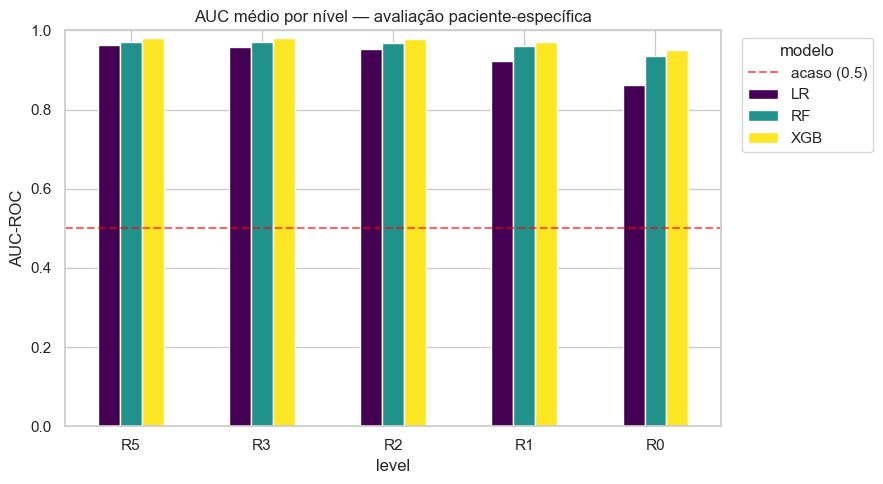

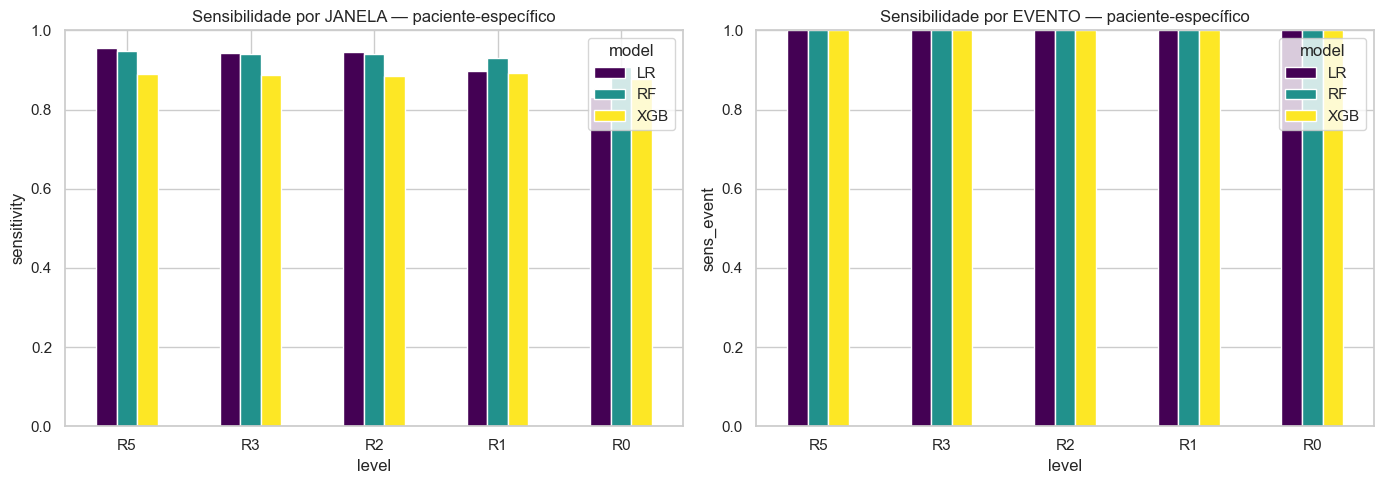

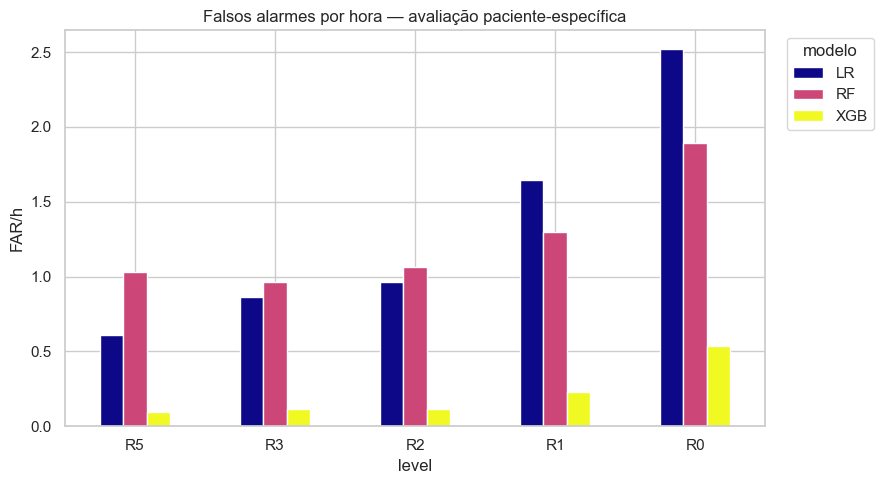


Diagnóstico de overfitting — gap AUC treino-validação (split por bloco temporal):
(gap = auc_tr_internal - auc_val_internal; quanto maior, mais sinal de overfitting)


,auc_tr_internal,auc_val_internal,overfit_gap
model,,,
LR,0.963,0.877,0.086
RF,0.996,0.904,0.092
XGB,1.000,0.905,0.095



Gap por nível e modelo:


model,LR,RF,XGB
level,,,
R5,0.081,0.069,0.070
R3,0.090,0.077,0.070
R2,0.091,0.076,0.073
R1,0.086,0.093,0.097
R0,0.083,0.129,0.144


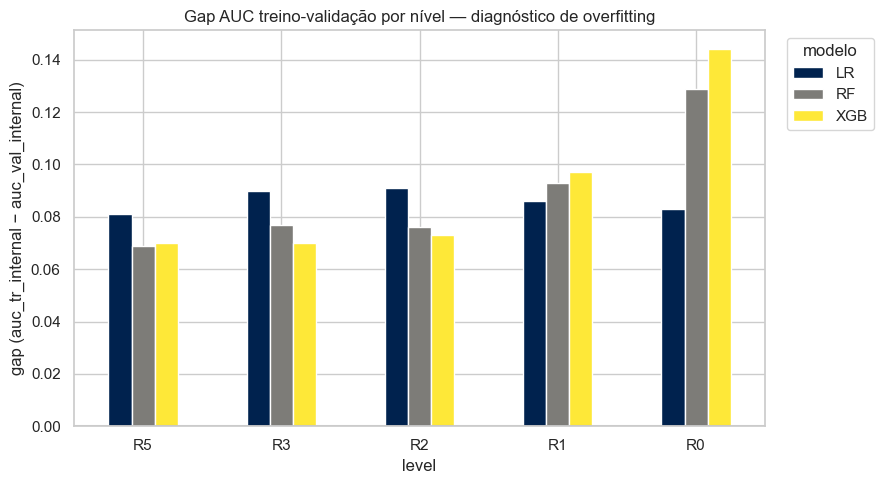

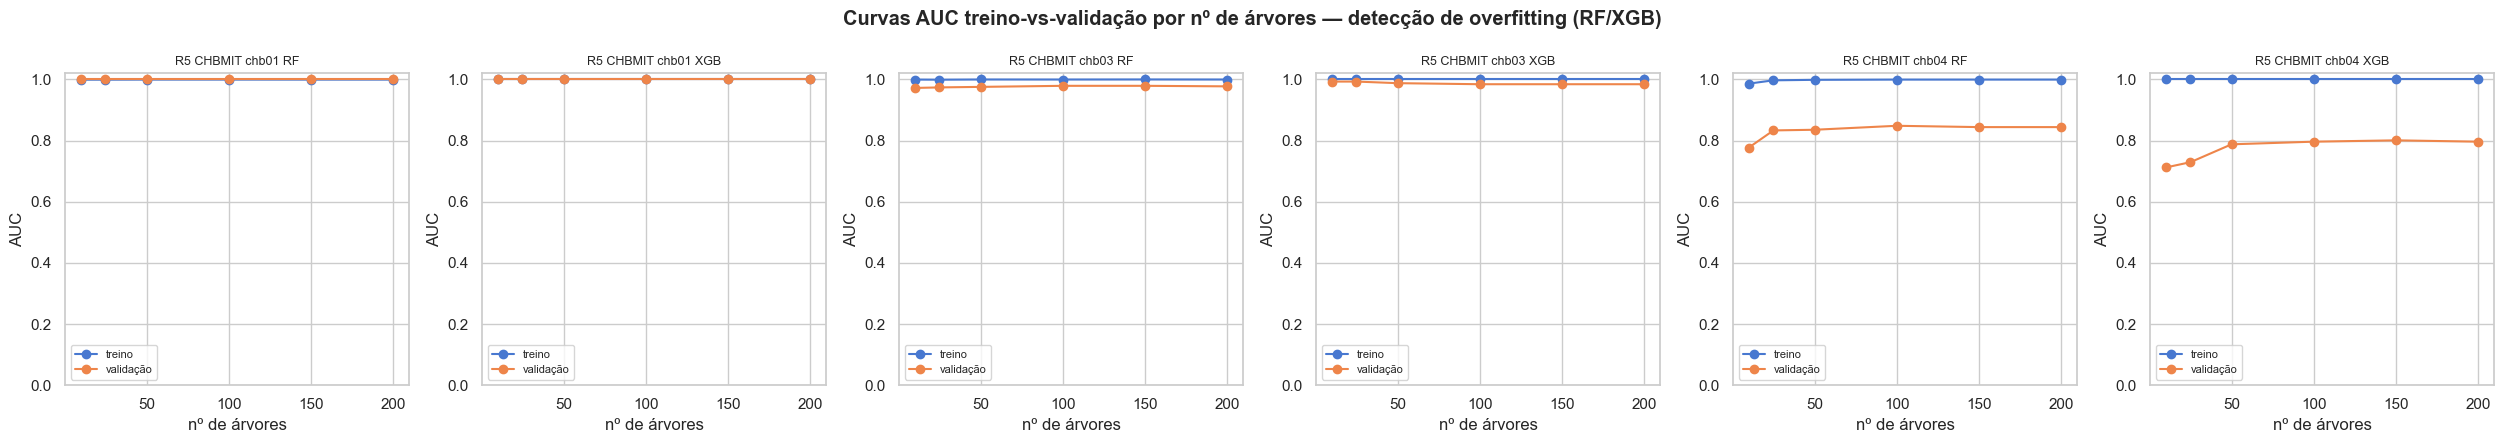


AUC médio geral: 0.952
Pipeline íntegro: o modelo distingue pré-ictal de interictal no próprio paciente.

Verificação concluída. Próximo: Notebook 4.


In [5]:
if os.path.exists(CSV_PS):
    df_ps = pd.read_csv(CSV_PS)

    # Métricas salvas no CSV (completo — disponível para análises posteriores)
    ALL_METRICS  = ['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'precision', 'far_window_h', 'sens_event', 'far_event_h']
    # Métricas exibidas nos outputs (as relevantes para o TCC)
    MAIN_METRICS = ['auc_roc', 'sensitivity', 'specificity', 'sens_event', 'far_event_h']

    # ── Tabela principal: métricas relevantes por dataset, nível e modelo ──
    print('Resumo por dataset, nível e modelo:')
    g = df_ps.groupby(['level', 'dataset', 'model'])[MAIN_METRICS].mean().round(3)
    ipd.display(g)

    # ── Média por modelo (todas as métricas salvas — não exibido, mas acessível) ──
    df_ps.groupby('model')[ALL_METRICS].mean().round(3).to_csv(
        os.path.join(RESULTS_DIR, 'ps_resumo_por_modelo.csv'))

    # ── Média por nível de canais ──
    print('\nImpacto da redução de canais (média sobre datasets e modelos):')
    gl = df_ps.groupby('level')[MAIN_METRICS].mean().reindex(LEVELS).round(3)
    ipd.display(gl)

    # ── Média por modelo ──
    print('\nComparação entre modelos (média sobre datasets e níveis):')
    gm = df_ps.groupby('model')[MAIN_METRICS].mean().round(3)
    ipd.display(gm)

    # ── Gráfico: AUC por nível e modelo ──
    fig, ax = plt.subplots(figsize=(9, 5))
    piv = df_ps.groupby(['level', 'model'])['auc_roc'].mean().unstack().reindex(LEVELS)
    piv.plot(kind='bar', ax=ax, colormap='viridis')
    ax.axhline(0.5, color='red', ls='--', alpha=0.6, label='acaso (0.5)')
    ax.set_title('AUC médio por nível — avaliação paciente-específica')
    ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1)
    ax.legend(title='modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'patient_specific_auc.png'), dpi=140, bbox_inches='tight')
    plt.show()

    # ── Gráfico: sensibilidade por JANELA vs por EVENTO ──
    # A primeira mede acerto amostra-a-amostra (do modelo); a segunda mede
    # acerto por evento clínico com a regra de N_CONSEC janelas seguidas
    # (depende do algoritmo de decisão, não só do modelo) — daí ficar perto
    # de 1.0 com mais facilidade.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    piv_sw = df_ps.groupby(['level', 'model'])['sensitivity'].mean().unstack().reindex(LEVELS)
    piv_sw.plot(kind='bar', ax=axes[0], colormap='viridis')
    axes[0].set_title('Sensibilidade por JANELA — paciente-específico')
    axes[0].set_ylabel('sensitivity'); axes[0].set_ylim(0, 1); axes[0].tick_params(axis='x', rotation=0)
    piv_se = df_ps.groupby(['level', 'model'])['sens_event'].mean().unstack().reindex(LEVELS)
    piv_se.plot(kind='bar', ax=axes[1], colormap='viridis')
    axes[1].set_title('Sensibilidade por EVENTO — paciente-específico')
    axes[1].set_ylabel('sens_event'); axes[1].set_ylim(0, 1); axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'patient_specific_sensibilidade_janela_vs_evento.png'), dpi=140, bbox_inches='tight')
    plt.show()

    # ── Gráfico: FAR/h por nível e modelo ──
    fig, ax = plt.subplots(figsize=(9, 5))
    piv2 = df_ps.groupby(['level', 'model'])['far_event_h'].mean().unstack().reindex(LEVELS)
    piv2.plot(kind='bar', ax=ax, colormap='plasma')
    ax.set_title('Falsos alarmes por hora — avaliação paciente-específica')
    ax.set_ylabel('FAR/h')
    ax.legend(title='modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'patient_specific_far.png'), dpi=140, bbox_inches='tight')
    plt.show()

    # ── Diagnóstico de overfitting: gap AUC treino-validação ──
    # Medido no MESMO split por bloco temporal usado no DL (Notebook 4.5).
    # Não afeta o modelo final (treinado com o conjunto de treino completo);
    # serve só para comparar o quanto cada modelo "decora" o treino.
    # Tabela impressa separadamente da figura, para não sobrepor a visualização.
    if 'overfit_gap' in df_ps.columns:
        print('\nDiagnóstico de overfitting — gap AUC treino-validação (split por bloco temporal):')
        print('(gap = auc_tr_internal - auc_val_internal; quanto maior, mais sinal de overfitting)')
        gap_tbl = df_ps.groupby('model')[['auc_tr_internal', 'auc_val_internal', 'overfit_gap']].mean().round(3)
        ipd.display(gap_tbl)

        gap_by_level = df_ps.groupby(['level', 'model'])['overfit_gap'].mean().unstack().reindex(LEVELS).round(3)
        print('\nGap por nível e modelo:')
        ipd.display(gap_by_level)

        fig, ax = plt.subplots(figsize=(9, 5))
        gap_by_level.plot(kind='bar', ax=ax, colormap='cividis')
        ax.axhline(0, color='gray', ls='-', alpha=0.4)
        ax.set_title('Gap AUC treino-validação por nível — diagnóstico de overfitting')
        ax.set_ylabel('gap (auc_tr_internal − auc_val_internal)')
        ax.legend(title='modelo', bbox_to_anchor=(1.02, 1), loc='upper left'); ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'patient_specific_overfit_gap.png'), dpi=140, bbox_inches='tight')
        plt.show()

    # ── Curvas AUC treino-vs-validação por número de árvores (RF/XGB) ──
    # Análogas às curvas de loss/AUC por época do DL. LR não tem uma curva
    # comparável (não "cresce" em complexidade ao longo do treino), por
    # isso aparece só na tabela de gap acima, não aqui.
    if OVERFIT_CURVES_PS:
        sample_keys = [k for k in OVERFIT_CURVES_PS if '_RF' in k or '_XGB' in k][:6]
        if sample_keys:
            fig, axes = plt.subplots(1, len(sample_keys), figsize=(4.2*len(sample_keys), 4.5))
            if len(sample_keys) == 1: axes = [axes]
            fig.suptitle('Curvas AUC treino-vs-validação por nº de árvores — detecção de overfitting (RF/XGB)',
                         fontweight='bold')
            for ax, key in zip(axes, sample_keys):
                c = OVERFIT_CURVES_PS[key]
                ax.plot(c['n_estimators'], c['auc_tr'], marker='o', label='treino')
                ax.plot(c['n_estimators'], c['auc_val'], marker='o', label='validação')
                title = key.replace('_', ' ')
                ax.set_title(title, fontsize=9)
                ax.set_xlabel('nº de árvores'); ax.set_ylabel('AUC'); ax.set_ylim(0, 1.02)
                ax.legend(fontsize=8)
            plt.tight_layout()
            plt.savefig(os.path.join(FIG_DIR, 'patient_specific_overfit_curves.png'), dpi=140, bbox_inches='tight')
            plt.show()

    auc_mean = df_ps['auc_roc'].mean()
    print(f'\nAUC médio geral: {auc_mean:.3f}')
    if auc_mean > 0.7:
        print('Pipeline íntegro: o modelo distingue pré-ictal de interictal no próprio paciente.')
    else:
        print('AUC baixo: revisar rótulos e features antes dos cenários A/B/C.')
else:
    print('Execute a seção 3 primeiro.')

print('\nVerificação concluída. Próximo: Notebook 4.')

## 5. Interpretabilidade — SHAP e Permutation Importance

Aplicada ao **modelo vencedor** (maior AUC médio no patient-specific) no nível R5 de cada dataset. Como o patient-specific tem AUC elevado, as features identificadas aqui representam o que de fato discrimina pré-ictal de interictal quando o modelo tem acesso ao próprio paciente — servindo de linha de base para comparar com os cenários generalizados do Notebook 4.

**Permutation Importance** mede a queda de AUC ao embaralhar cada feature no conjunto de teste — captura importância para generalização, não apenas para ajuste ao treino.

**SHAP** calcula a contribuição marginal de cada feature por amostra, com o beeswarm plot mostrando direção (features que empurram a predição para pré-ictal vs. interictal) e magnitude.



CHBMIT/R5 — modelo vencedor: XGB
  Permutation Importance (10 repetições)...
  SHAP (300 amostras)...


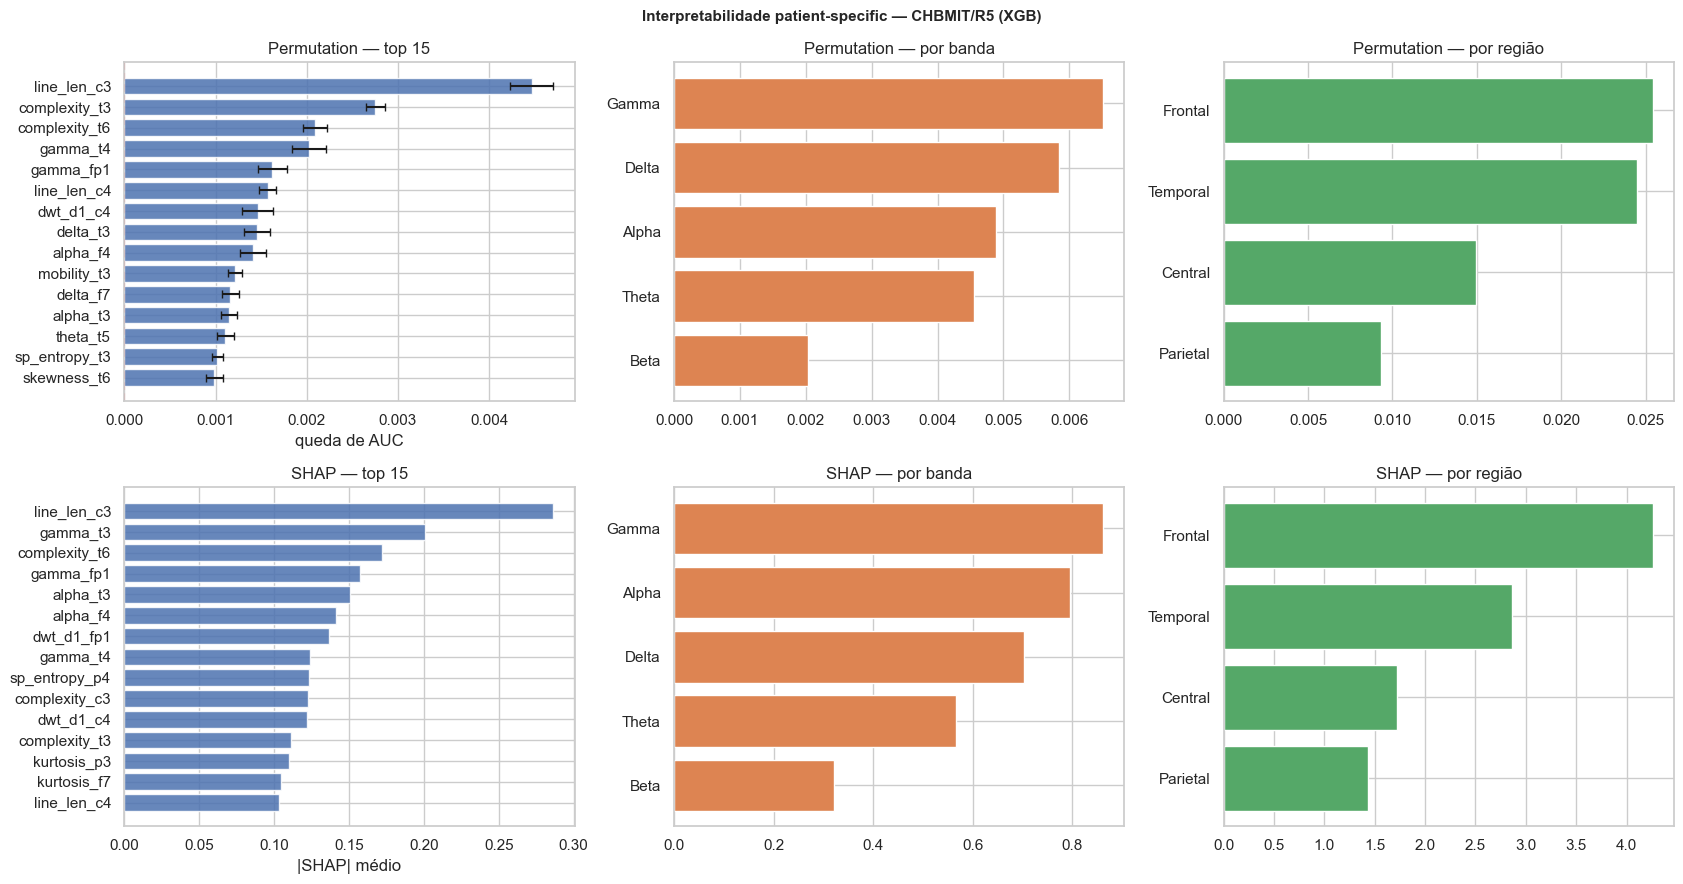

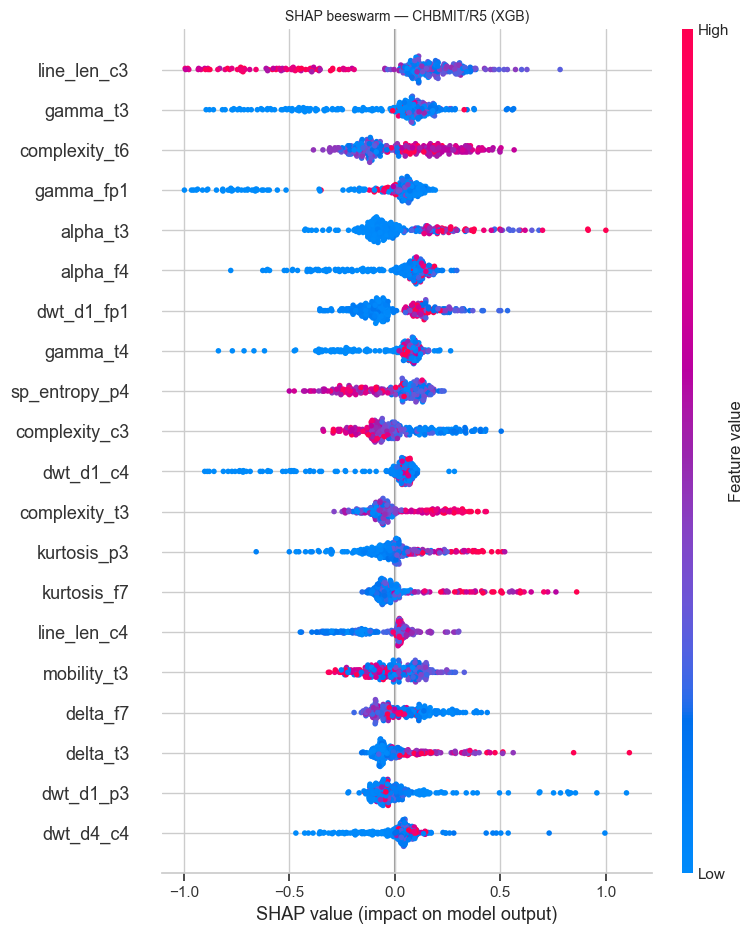

  Top 5 Permutation: ['line_len_c3', 'complexity_t3', 'complexity_t6', 'gamma_t4', 'gamma_fp1']
  Top 5 SHAP:        ['line_len_c3', 'gamma_t3', 'complexity_t6', 'gamma_fp1', 'alpha_t3']

Siena/R5 — modelo vencedor: XGB
  Permutation Importance (10 repetições)...
  SHAP (300 amostras)...


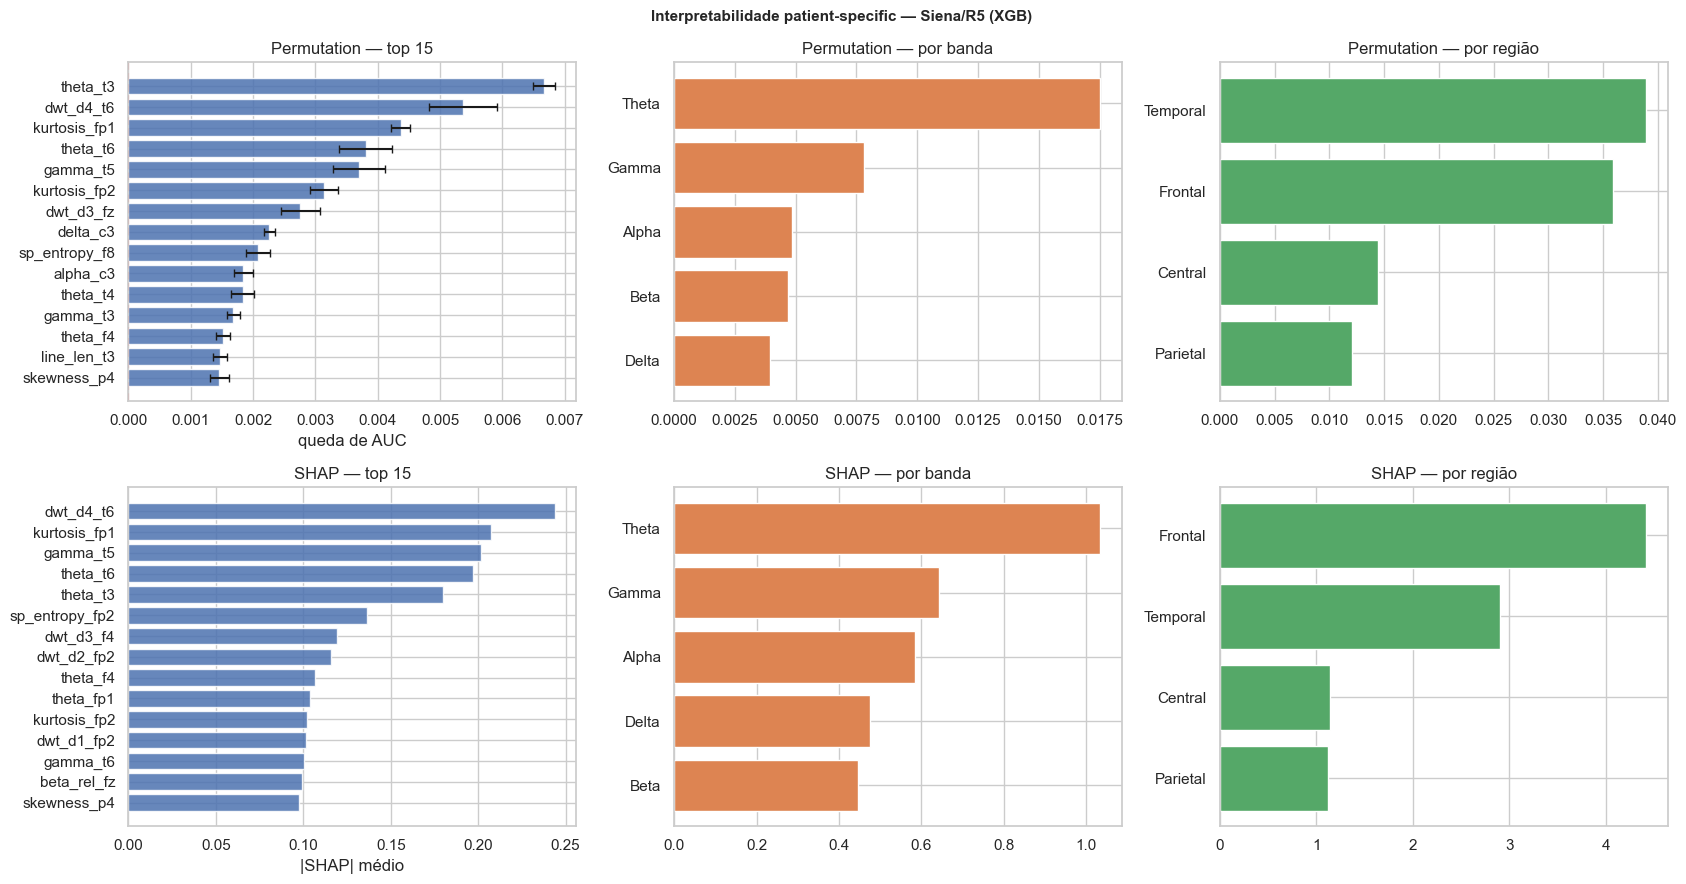

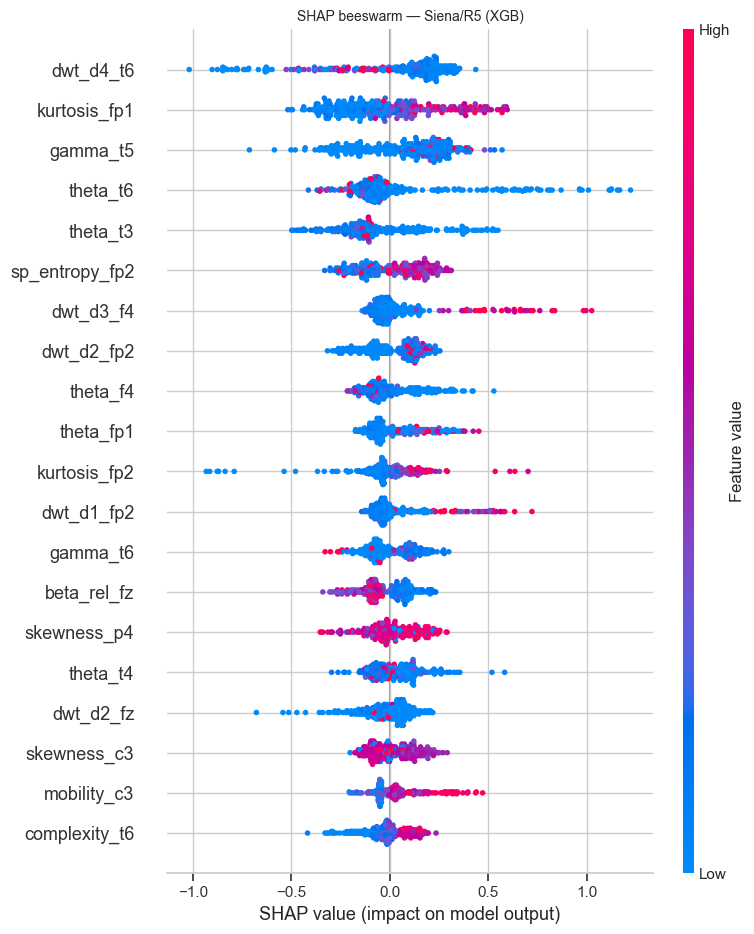

  Top 5 Permutation: ['theta_t3', 'dwt_d4_t6', 'kurtosis_fp1', 'theta_t6', 'gamma_t5']
  Top 5 SHAP:        ['dwt_d4_t6', 'kurtosis_fp1', 'gamma_t5', 'theta_t6', 'theta_t3']

Mendeley/R5 — modelo vencedor: XGB
  Permutation Importance (10 repetições)...
  SHAP (300 amostras)...


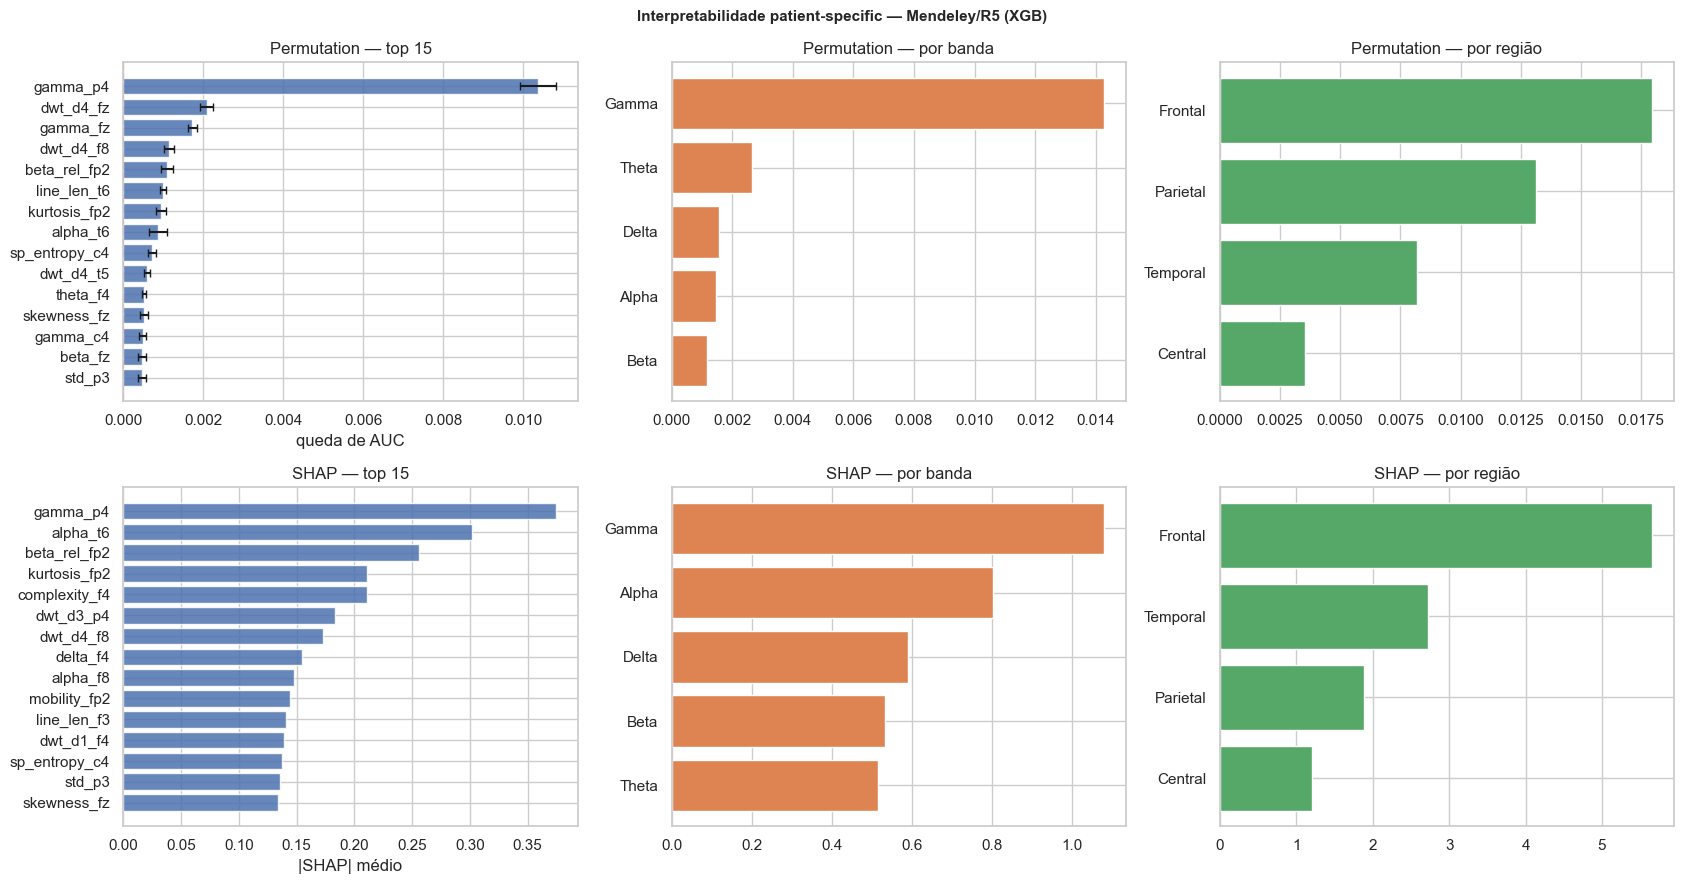

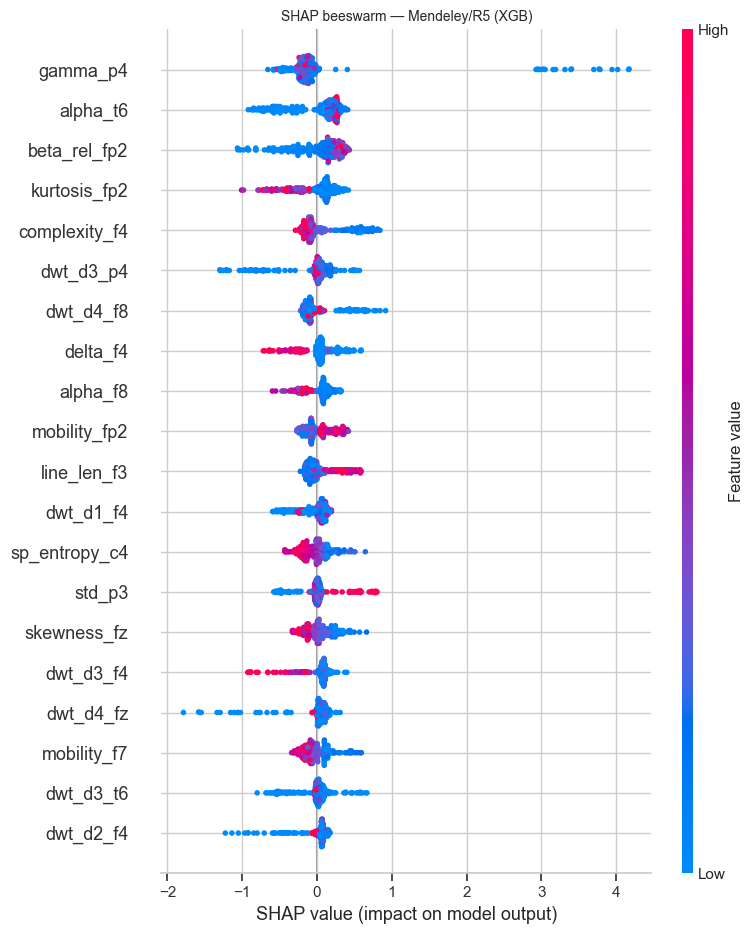

  Top 5 Permutation: ['gamma_p4', 'dwt_d4_fz', 'gamma_fz', 'dwt_d4_f8', 'beta_rel_fp2']
  Top 5 SHAP:        ['gamma_p4', 'alpha_t6', 'beta_rel_fp2', 'kurtosis_fp2', 'complexity_f4']

SeizeIT2/R0 — modelo vencedor: XGB
  Permutation Importance (10 repetições)...
  SHAP (300 amostras)...


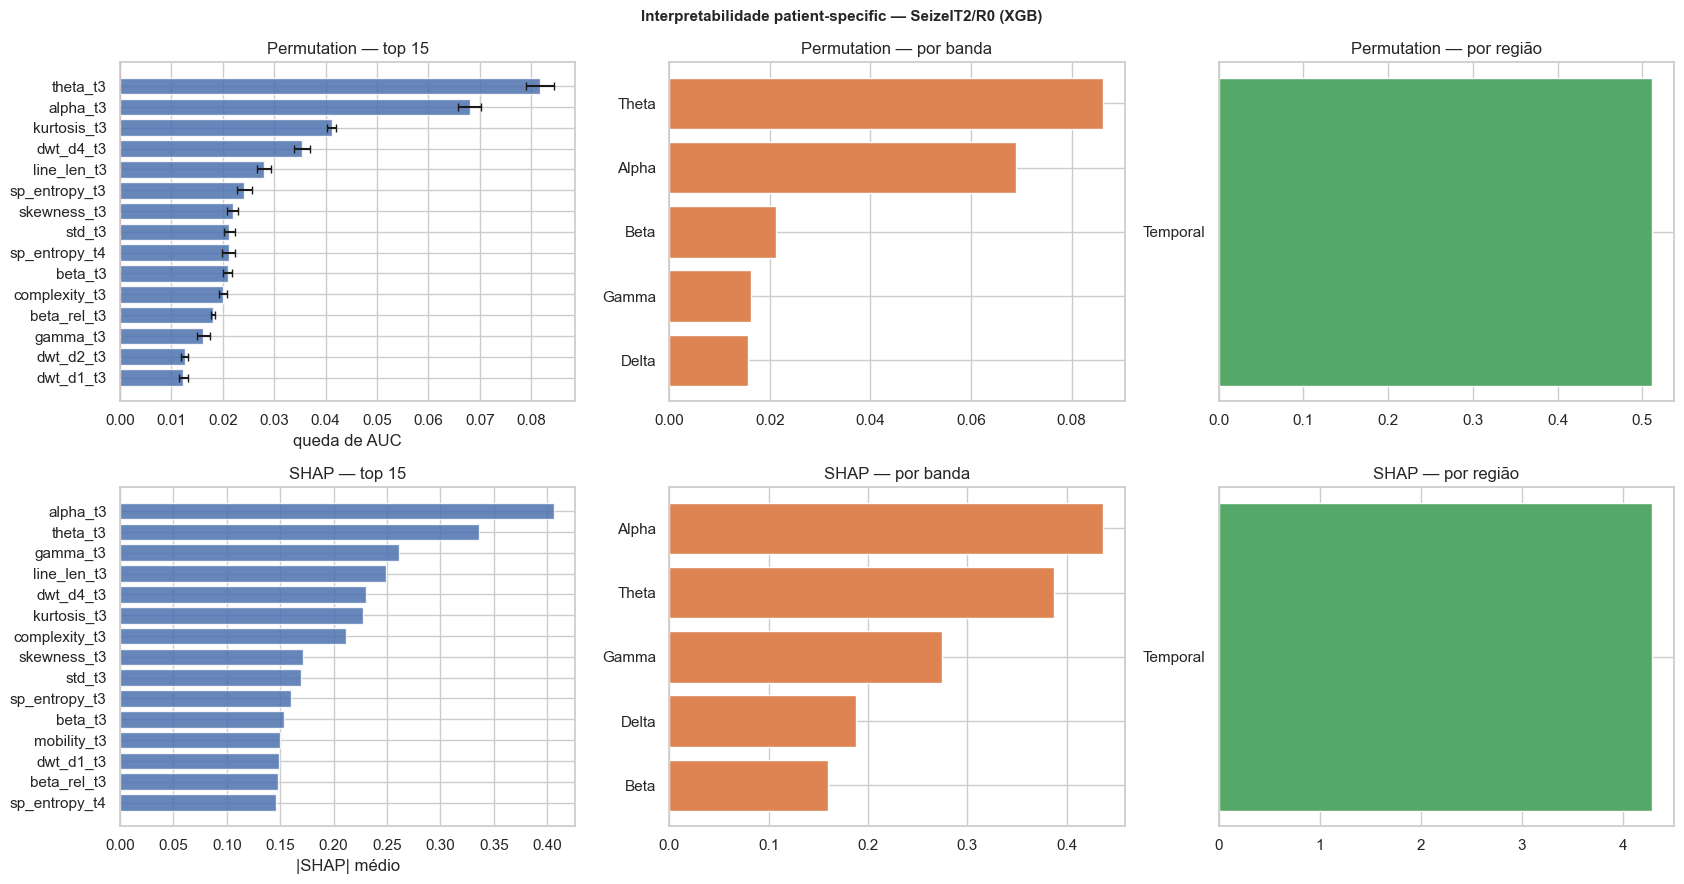

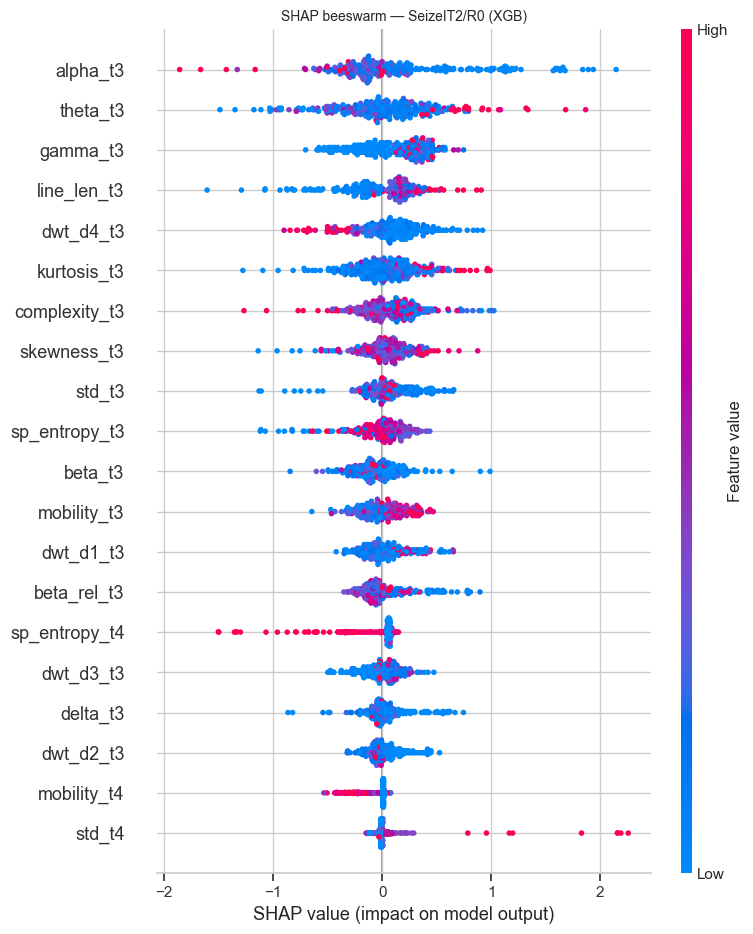

  Top 5 Permutation: ['theta_t3', 'alpha_t3', 'kurtosis_t3', 'dwt_d4_t3', 'line_len_t3']
  Top 5 SHAP:        ['alpha_t3', 'theta_t3', 'gamma_t3', 'line_len_t3', 'dwt_d4_t3']


In [6]:
import shap
from sklearn.inspection import permutation_importance

INTERP_LEVEL   = 'R5'
INTERP_N_REPEAT = 10
SHAP_MAX_SAMPLES = 300

def run_interpretability(dataset, level=INTERP_LEVEL):
    '''SHAP + Permutation Importance no modelo vencedor para um dataset.'''
    if not os.path.exists(CSV_PS):
        print('Execute a seção 3 primeiro.'); return

    df_ps = pd.read_csv(CSV_PS)
    sub = df_ps[(df_ps['dataset'] == dataset) & (df_ps['level'] == level)]
    if sub.empty:
        print(f'Sem resultados para {dataset}/{level}.'); return

    model_name = sub.groupby('model')['auc_roc'].mean().idxmax()
    print(f'{dataset}/{level} — modelo vencedor: {model_name}')

    # Carregar features de todos os pacientes do dataset neste nível
    Xtr, ytr, Xte, yte = [], [], [], []
    for p in PATIENTS.get(dataset, []):
        X, y = load_feat(dataset, p, level, 'train')
        if X is not None and len(X) > 0: Xtr.append(X); ytr.append(y)
        X, y = load_feat(dataset, p, level, 'test')
        if X is not None and len(X) > 0: Xte.append(X); yte.append(y)
    if not Xtr or not Xte:
        print('Features não encontradas.'); return

    X_tr = np.concatenate(Xtr); y_tr = np.concatenate(ytr)
    X_te = np.concatenate(Xte); y_te = np.concatenate(yte)
    sc = StandardScaler(); X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)

    clf = get_model(model_name); clf.fit(X_tr_sc, y_tr)

    CHANNEL_SETS = {
        'R5': ['fp1','fp2','f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4','p3','p4'],
        'R3': ['f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4'],
        'R2': ['f7','f3','fz','f4','f8','t3','t4','t5','t6'],
        'R1': ['t3','t4','t5','t6'], 'R0': ['t3','t4'],
    }
    FEAT_NAMES_BASE = ['std','var','rms','line_len','mobility','skewness','kurtosis',
                       'delta','theta','alpha','beta','gamma','sp_entropy','beta_rel',
                       'dwt_d1','dwt_d2','dwt_d3','dwt_d4','complexity']
    CH_REGION = {}
    for ch in ['fp1','fp2','f7','f3','fz','f4','f8']: CH_REGION[ch]='Frontal'
    for ch in ['t3','t4','t5','t6']: CH_REGION[ch]='Temporal'
    for ch in ['c3','c4']: CH_REGION[ch]='Central'
    for ch in ['p3','p4']: CH_REGION[ch]='Parietal'
    BAND_FEATS = {'delta':'Delta','theta':'Theta','alpha':'Alpha','beta':'Beta','gamma':'Gamma'}

    feat_names = [f'{f}_{ch}' for ch in CHANNEL_SETS[level] for f in FEAT_NAMES_BASE]

    # ── Permutation Importance ──
    print(f'  Permutation Importance ({INTERP_N_REPEAT} repetições)...')
    perm = permutation_importance(clf, X_te_sc, y_te, scoring='roc_auc',
                                  n_repeats=INTERP_N_REPEAT, n_jobs=4, random_state=42)
    df_perm = pd.DataFrame({'feature': feat_names,
                            'importance': perm.importances_mean,
                            'std': perm.importances_std})
    df_perm['base']   = df_perm['feature'].apply(lambda s: s.rsplit('_',1)[0])
    df_perm['chan']   = df_perm['feature'].apply(lambda s: s.rsplit('_',1)[1])
    df_perm['regiao'] = df_perm['chan'].map(CH_REGION).fillna('Outro')
    df_perm['banda']  = df_perm['base'].map(BAND_FEATS).fillna('-')
    df_perm = df_perm.sort_values('importance', ascending=False).reset_index(drop=True)
    df_perm.to_csv(os.path.join(RESULTS_DIR, f'ps_permutation_{dataset}_{level}.csv'), index=False)

    # ── SHAP ──
    print(f'  SHAP ({SHAP_MAX_SAMPLES} amostras)...')
    rng = np.random.default_rng(42)
    idx0 = np.where(y_te == 0)[0]; idx1 = np.where(y_te == 1)[0]
    n_each = min(SHAP_MAX_SAMPLES // 2, len(idx0), len(idx1))
    idx_s = np.sort(np.concatenate([rng.choice(idx0, n_each, replace=False),
                                     rng.choice(idx1, n_each, replace=False)]))
    X_shap = X_te_sc[idx_s]; y_shap = y_te[idx_s]

    if model_name in ('RF', 'XGB'):
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_shap)
        if isinstance(sv, list): sv = sv[1]
        elif hasattr(sv, 'ndim') and sv.ndim == 3: sv = sv[:, :, 1]
    else:
        explainer = shap.LinearExplainer(clf, X_tr_sc)
        sv = explainer.shap_values(X_shap)

    shap_mean = np.abs(sv).mean(axis=0)
    df_shap = pd.DataFrame({'feature': feat_names, 'shap_mean': shap_mean})
    df_shap['base']   = df_shap['feature'].apply(lambda s: s.rsplit('_',1)[0])
    df_shap['chan']   = df_shap['feature'].apply(lambda s: s.rsplit('_',1)[1])
    df_shap['regiao'] = df_shap['chan'].map(CH_REGION).fillna('Outro')
    df_shap['banda']  = df_shap['base'].map(BAND_FEATS).fillna('-')
    df_shap = df_shap.sort_values('shap_mean', ascending=False).reset_index(drop=True)
    df_shap.to_csv(os.path.join(RESULTS_DIR, f'ps_shap_{dataset}_{level}.csv'), index=False)

    # ── Gráficos ──
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle(f'Interpretabilidade patient-specific — {dataset}/{level} ({model_name})',
                 fontweight='bold', fontsize=11)

    # Permutation top 15
    top_p = df_perm.head(15).iloc[::-1]
    axes[0,0].barh(top_p['feature'], top_p['importance'], xerr=top_p['std'],
                   color='#4C72B0', alpha=0.85, capsize=3)
    axes[0,0].axvline(0, color='red', ls='--', alpha=0.5)
    axes[0,0].set_title('Permutation — top 15'); axes[0,0].set_xlabel('queda de AUC')

    band_p = df_perm[df_perm['banda']!='-'].groupby('banda')['importance'].sum().sort_values()
    axes[0,1].barh(band_p.index, band_p.values, color='#DD8452')
    axes[0,1].set_title('Permutation — por banda')

    reg_p = df_perm.groupby('regiao')['importance'].sum().sort_values()
    axes[0,2].barh(reg_p.index, reg_p.values, color='#55A868')
    axes[0,2].set_title('Permutation — por região')

    # SHAP top 15
    top_s = df_shap.head(15).iloc[::-1]
    axes[1,0].barh(top_s['feature'], top_s['shap_mean'], color='#4C72B0', alpha=0.85)
    axes[1,0].set_title('SHAP — top 15'); axes[1,0].set_xlabel('|SHAP| médio')

    band_s = df_shap[df_shap['banda']!='-'].groupby('banda')['shap_mean'].sum().sort_values()
    axes[1,1].barh(band_s.index, band_s.values, color='#DD8452')
    axes[1,1].set_title('SHAP — por banda')

    reg_s = df_shap.groupby('regiao')['shap_mean'].sum().sort_values()
    axes[1,2].barh(reg_s.index, reg_s.values, color='#55A868')
    axes[1,2].set_title('SHAP — por região')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'ps_interpretabilidade_{dataset}_{level}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

    # Beeswarm SHAP
    fig2, ax2 = plt.subplots(figsize=(10, 7))
    shap.summary_plot(sv, X_shap, feature_names=feat_names, max_display=20,
                      show=False, plot_type='dot')
    plt.title(f'SHAP beeswarm — {dataset}/{level} ({model_name})', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'ps_shap_beeswarm_{dataset}_{level}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

    print(f'  Top 5 Permutation: {df_perm["feature"].head(5).tolist()}')
    print(f'  Top 5 SHAP:        {df_shap["feature"].head(5).tolist()}')

# Rodar para cada dataset no nível R5
for ds in ['CHBMIT', 'Siena', 'Mendeley']:
    print(f'\n{"="*50}')
    run_interpretability(ds, level='R5')

# SeizeIT2 só tem R0
print(f'\n{"="*50}')
run_interpretability('SeizeIT2', level='R0')